# Inference About the Mean: The Equity Premium

This notebook covers statistical inference about a population mean, using the equity premium as the running example. It draws directly on the Week 1 notes (`notes/week01_estimating_the_mean.md`) and on the two earlier simulation notebooks, `SampleMeanSimulation.ipynb` and `SampleVarianceSimulation.ipynb` -- if any step here feels unfamiliar, those are the places to go back to.

*Acknowledgment*: This notebook was produced with the assistance of AI. I remain responsible for the content and any errors.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why estimating the equity premium is, at its core, the same statistical problem as estimating any unknown population mean from a finite sample.
2. State the classical i.i.d. Normal assumptions for a return series, and identify the three separate pieces (identically distributed, independent, Normal) that go into them.
3. Derive the mean and variance of the sample mean $\bar R$, and explain exactly which assumption is doing the work at each step.
4. Explain where the chi-squared distribution comes from, and state (without full proof) why $(T-1)s^2/\sigma^2 \sim \chi^2_{T-1}$.
5. Derive the Student-$t$ result for $(\bar R - \mu)/(s/\sqrt T)$ and use it to construct an exact confidence interval and hypothesis test for $\mu$.
6. Use simulation to verify all of the above results numerically, including the exact coverage of a classical confidence interval.
7. Explain which of the classical assumptions are most likely violated by real return data, and why that matters for inference.
8. Simulate a dependent (AR(1)) return series and show, via simulation, that naive standard errors understate the true uncertainty in $\bar R$ when returns are autocorrelated.
9. Explain the idea behind a Newey-West (HAC) standard error and show, via simulation, that it restores approximately correct confidence-interval coverage under dependence.
10. Apply this machinery to real monthly U.S. market excess return data to estimate, and quantify the uncertainty around, the historical equity premium.

## Instructions to Run

**Data file needed:** `market_excess_monthly.csv`

**Where to get it:** This dataset (monthly U.S. market excess returns) is not yet included in this repo. It will be posted on the course Canvas site under Data -- download it into your local `data/` folder before running the final (Application) section of this notebook. Every other section runs immediately, since it relies only on simulated data.

**Expected format:** two columns, `date` and `mkt_excess`, with `mkt_excess` expressed in **percent** (e.g. `0.85` for a monthly excess return of 0.85%), matching the convention used by the Fama-French Data Library.

**If your data lives somewhere else:** The Application section loads the CSV with `pd.read_csv("../data/market_excess_monthly.csv", ...)`. Edit that path if you've placed the file elsewhere.

**Package dependencies:** `pandas`, `numpy`, `matplotlib`, `scipy` -- all standard scientific-Python packages, included in a typical Anaconda install. Otherwise: `pip install pandas numpy matplotlib scipy`.

## Motivation: The Equity Premium Is a Mean-Estimation Problem

The **equity premium** is the average return, per year, that an investor earns from holding "the market" -- a broad, diversified portfolio of U.S. stocks -- in excess of the risk-free rate. It is arguably *the* number in asset pricing: it anchors discount rates for capital budgeting, expected returns for retirement planning, and just about every "is this investment worth it" calculation you'll do this semester.

And yet, despite roughly a century of high-quality return data, economists still disagree about its value and about how much uncertainty surrounds it. That's not primarily a data problem -- it's a *statistics* problem, and it's exactly the problem you already met, in miniature, in `SampleMeanSimulation.ipynb`: **a sample mean computed from a finite sample is a noisy estimate of an unknown, fixed population quantity.**

In `Security_Returns_Properties.ipynb`, we saw that USO and SPY daily returns are visibly fat-tailed and far from Normal. That matters here too: it's part of why estimating something as seemingly simple as "the average return" honestly -- with a defensible sense of how much uncertainty surrounds the estimate -- turns out to be genuinely hard. If you can precisely state what is, and isn't, justified about inference on a sample mean, you can precisely state what is and isn't justified about the equity premium. That's the goal of this notebook.

## The Classical Setup

Let $R_t$ denote the market's realized excess return in year $t$, for $t=1,\dots,T$. The classical, "intro stats" starting point is to assume

$$R_t \overset{\text{i.i.d.}}{\sim} N(\mu, \sigma^2), \qquad t=1,\dots,T$$

This bundles together three separate, separately violable assumptions -- worth naming now, since we'll examine each one on its own later:

1. **Identically distributed** -- $\mu$ and $\sigma^2$ are the same in every year; there is one fixed number $\mu$, the equity premium, that we're trying to learn.
2. **Independent** -- knowing last year's excess return tells you nothing about this year's.
3. **Normal** -- each $R_t$ individually follows a Normal distribution.

$\mu$ is the object we actually care about: the equity premium. $\sigma^2$ is a nuisance parameter we'll have to deal with along the way.

This is exactly the setup simulated in `SampleMeanSimulation.ipynb`, with $\mu=5$ and $\sigma=10$ standing in for whatever the "true" equity premium and return volatility might be. We'll reuse those same numbers below.

## Exact Inference Under the Classical Assumptions

### Three probability facts

Everything below is bookkeeping on top of three general facts about expectation and variance.

**Fact 1 (linearity of expectation).** For any constants $a,b$ and any random variables $X,Y$ -- no independence, Normality, or relationship between them required:

$$E(aX+bY) = aE(X) + bE(Y), \qquad E\!\left(\sum_{t=1}^T a_t X_t\right) = \sum_{t=1}^T a_t E(X_t)$$

**Fact 2 (variance of a sum).** Variance is *not* linear, but: $\text{Var}(aX) = a^2\text{Var}(X)$ (no independence needed -- one random variable), and for *independent* (or merely uncorrelated) $X,Y$: $\text{Var}(X+Y) = \text{Var}(X)+\text{Var}(Y)$. In general $\text{Var}(X+Y) = \text{Var}(X)+\text{Var}(Y)+2\,\text{Cov}(X,Y)$, and the cross term only vanishes under independence (or zero correlation) -- flag this one, it's exactly the ingredient that fails once returns are autocorrelated, later in this notebook.

**Fact 3 (Normal is closed under linear combinations).** If $X,Y$ are (possibly correlated) Normal random variables, then $aX+bY$ is *itself* exactly Normal, for any constants $a,b$. This is special to the Normal family, and it's what lets us upgrade "each $R_t$ is Normal" to "$\bar R$ is Normal" below, rather than merely approximately so.

### The sample mean and its exact sampling distribution

Our estimator of $\mu$ is the sample mean, $\bar R = \frac{1}{T}\sum_{t=1}^T R_t$.

**Unbiasedness**, from Fact 1 -- note this step needs *nothing* about independence:

$$E(\bar R) = \frac{1}{T}\sum_{t=1}^T E(R_t) \overset{\text{ident. dist.}}{=} \frac{1}{T}(T\mu) = \mu$$

Only the "identically distributed" assumption is used here ($E(R_t)=\mu$ for every $t$); independence never enters. **Unbiasedness of the sample mean does not require independence across time.**

**Variance**, from Fact 2 -- here independence *does* enter:

$$\text{Var}(\bar R) = \frac{1}{T^2}\text{Var}\!\left(\sum_{t=1}^T R_t\right) \overset{\text{independence}}{=} \frac{1}{T^2}\sum_{t=1}^T \text{Var}(R_t) \overset{\text{ident. dist.}}{=} \frac{1}{T^2}(T\sigma^2) = \frac{\sigma^2}{T}$$

So $\bar R$ is unbiased and its spread shrinks at rate $1/\sqrt T$. Now bring in Fact 3: since each $R_t\sim N(\mu,\sigma^2)$ and $\bar R$ is a linear combination of independent Normal random variables, $\bar R$ is *itself* exactly Normal, for **any** $T$, not just approximately for large $T$:

$$\bar R \sim N\left(\mu, \frac{\sigma^2}{T}\right) \quad \text{exactly, for every } T$$

This exactness comes entirely from Fact 3 -- a property of the Normal distribution specifically. It's the first thing to go once we relax Normality later in this notebook.

### The sample variance, and where the chi-squared distribution comes from

We also need an estimator of $\sigma^2$. Define the (unbiased) **sample variance**

$$s^2 = \frac{1}{T-1}\sum_{t=1}^T (R_t - \bar R)^2$$

**Definition (chi-squared).** If $Z_1,\dots,Z_k$ are i.i.d. $N(0,1)$, their sum of squares $W=Z_1^2+\cdots+Z_k^2$ follows a **chi-squared distribution with $k$ degrees of freedom**, $W\sim\chi^2_k$. Properties we'll use: $\chi^2_k \geq 0$, right-skewed for small $k$; $E(W)=k$; $\text{Var}(W)=2k$; and independent chi-squared pieces add their degrees of freedom.

Since each $R_t\sim N(\mu,\sigma^2)$ i.i.d., the standardized deviations $(R_t-\mu)/\sigma$ are i.i.d. standard Normal, so directly from the definition, $\sum_{t=1}^T \left(\frac{R_t-\mu}{\sigma}\right)^2 \sim \chi^2_T$. The problem is that this uses the unknown $\mu$; $s^2$ uses $\bar R$ instead. Writing $R_t-\mu = (R_t-\bar R)+(\bar R-\mu)$ and expanding the square, the cross term vanishes when summed over $t$ (since $\sum_t (R_t-\bar R)=0$), leaving the identity

$$\sum_{t=1}^T (R_t-\mu)^2 = \sum_{t=1}^T (R_t-\bar R)^2 + T(\bar R-\mu)^2$$

Dividing by $\sigma^2$:

$$\underbrace{\sum_{t=1}^T\left(\frac{R_t-\mu}{\sigma}\right)^2}_{\sim\ \chi^2_T} = \underbrace{\frac{(T-1)s^2}{\sigma^2}}_{\text{what we want}} + \underbrace{\left(\frac{\bar R-\mu}{\sigma/\sqrt T}\right)^2}_{\sim\ \chi^2_1}$$

The last term is $\chi^2_1$ because it's the square of a single standard Normal (we just showed $\bar R\sim N(\mu,\sigma^2/T)$ exactly). A result called **Cochran's theorem** (named for the statistician William Cochran; we won't prove it here) guarantees that the two pieces on the right are *independent*, and that their degrees of freedom add -- so the piece we want must have $T-1$:

$$\frac{(T-1)s^2}{\sigma^2} \sim \chi^2_{T-1}$$

Intuition for the $T-1$: the $T$ deviations $R_t-\bar R$ are constrained to sum to exactly zero (that's what defines $\bar R$), so only $T-1$ of them are free to vary -- one degree of freedom is "spent" estimating $\mu$. Cochran's theorem is also *why* $\bar R$ and $s^2$ turn out to be **independent** of one another under these classical assumptions, a fact we lean on next.

Two quick corollaries follow directly from the chi-squared mean and variance ($k=T-1$): $E(s^2)=\sigma^2$ (unbiasedness) and $\text{Var}(s^2) = \dfrac{2\sigma^4}{T-1}$.

### The nuisance parameter problem, and the $t$-distribution

The formula $\bar R\sim N(\mu,\sigma^2/T)$ requires $\sigma^2$, which we don't know. Plugging in $s^2$ introduces extra sampling variability, so the standardized mean is no longer exactly standard Normal. The Student-$t$ distribution with $k$ degrees of freedom is, by definition, what you get from dividing a standard Normal by an independent $\sqrt{\chi^2_k/k}$. Using $Z=\frac{\bar R-\mu}{\sigma/\sqrt T}$ and $W=\frac{(T-1)s^2}{\sigma^2}$ (independent, from above), the unknown $\sigma$ cancels algebraically:

$$\frac{Z}{\sqrt{W/(T-1)}} = \frac{\bar R-\mu}{s/\sqrt T} \sim t_{T-1}$$

which gives an **exact** confidence interval for the equity premium,

$$\bar R \;\pm\; t_{T-1,\,0.975}\cdot\frac{s}{\sqrt T}$$

and an exact hypothesis test (e.g. $H_0:\mu=0$ -- "is there an equity premium at all?") using the $t_{T-1}$ distribution rather than the Normal. Everything in this section is mathematically *exact* -- conditional on the classical assumptions holding exactly. Let's check that with simulation before asking what happens when they don't.

**Questions**

1. Which single step in the unbiasedness derivation above would break if returns were not identically distributed over time (e.g. if the true equity premium had shifted after some structural change)?
2. Which single step in the variance derivation would break if returns were autocorrelated? What would you expect that to do to the *true* variance of $\bar R$, relative to $\sigma^2/T$?
3. As $T\to\infty$, the $t_{T-1}$ distribution converges to standard Normal. Why does that make the classical exact interval and the familiar "$\pm 1.96\times$ SE" approximate interval effectively the same in large samples?

## Illustrating the Classical Result via Simulation

We'll now reuse the exact setup from `SampleMeanSimulation.ipynb` -- $\mu=5$, $\sigma=10$, sample size $T=100$ -- and check *four* things by simulation: that $\bar R$ is unbiased with variance $\sigma^2/T$; that $(T-1)s^2/\sigma^2$ really does look chi-squared; that the $t$-statistic really does look $t_{T-1}$; and that a nominal 95% confidence interval really does cover $\mu$ about 95% of the time.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# true parameters (same as SampleMeanSimulation.ipynb)
mu = 5      # true mean (a stylized equity premium, in percent per year)
sigma = 10  # true std. dev. (in percent per year)

# sample size (same as SampleMeanSimulation.ipynb)
T = 100

print(T)

100


### One sample

As before, one simulated sample illustrates that both the sample mean and sample variance miss the truth -- pure sampling error.

In [2]:
rng = np.random.RandomState(10)  # deterministic random data, same seed as SampleMeanSimulation.ipynb
sim_R = rng.normal(loc=mu, scale=sigma, size=T)

Rbar = np.mean(sim_R)
s2 = np.var(sim_R, ddof=1)

print(f"Sample mean: {Rbar:.3f}   (true mean: {mu})")
print(f"Sample variance: {s2:.3f}   (true variance: {sigma**2})")

Sample mean: 5.794   (true mean: 5)
Sample variance: 94.461   (true variance: 100)


### Many simulations

Now we repeat this $B=5000$ times, keeping track of the sample mean, the sample variance, the $t$-statistic $(\bar R-\mu)/(s/\sqrt T)$, and whether the classical 95% confidence interval covers the true $\mu$, for every replication.

In [3]:
B = 5000

sim_means = []
sim_vars = []
sim_tstats = []
sim_ci_covers = []

t_crit = stats.t.ppf(0.975, df=T - 1)

for i in np.arange(0, B):
    sim_R = np.random.normal(loc=mu, scale=sigma, size=T)
    Rbar = np.mean(sim_R)
    s2 = np.var(sim_R, ddof=1)
    se = np.sqrt(s2 / T)
    tstat = (Rbar - mu) / se
    ci_lower = Rbar - t_crit * se
    ci_upper = Rbar + t_crit * se
    covers = (ci_lower <= mu) and (mu <= ci_upper)

    sim_means.append(Rbar)
    sim_vars.append(s2)
    sim_tstats.append(tstat)
    sim_ci_covers.append(covers)

sim_df = pd.DataFrame({
    "Rbar": sim_means,
    "s2": sim_vars,
    "tstat": sim_tstats,
    "ci_covers": sim_ci_covers,
})
sim_df.head()

,Rbar,s2,tstat,ci_covers
0,6.600911,99.989243,1.600997,True
1,4.918339,95.269229,-0.083664,True
2,6.859899,83.185254,2.039230,False
3,5.476069,99.542235,0.477163,True
4,3.004875,98.467889,-2.010586,False


In [4]:
sim_df[["Rbar", "s2"]].describe()

,Rbar,s2
count,5000.000000,5000.000000
mean,4.985652,99.843628
std,1.002018,14.176955
min,1.514978,57.290035
25%,4.313792,89.904508
50%,4.983151,99.250097
75%,5.659366,109.126003
max,8.488327,159.917671


### Interpretation

The theoretical results are $E(\bar R)=\mu=5$ and $\text{Std. Dev.}(\bar R) = \sigma/\sqrt T = 10/\sqrt{100} = 1$. The simulated mean and standard deviation of `Rbar` above should be very close to 5 and 1 -- and they are, up to simulation error that would shrink further with a larger $B$.

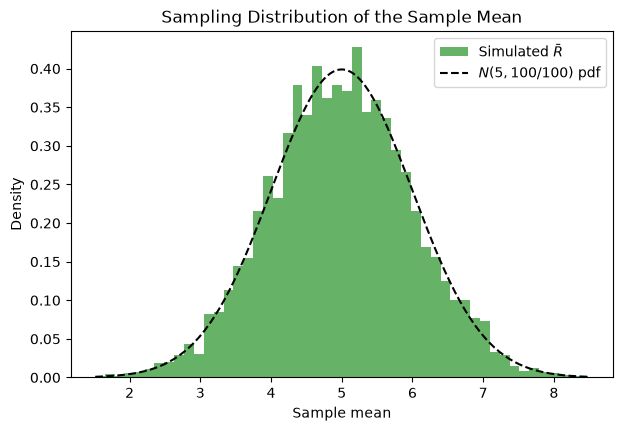

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sim_df["Rbar"], bins=50, density=True, alpha=0.6, color="green", label=r"Simulated $\bar R$")

x = np.linspace(sim_df["Rbar"].min(), sim_df["Rbar"].max(), 200)
ax.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma / np.sqrt(T)), color="black", linestyle="--",
        label=fr"$N({mu}, {sigma**2}/{T})$ pdf")

ax.set_xlabel("Sample mean")
ax.set_ylabel("Density")
ax.set_title("Sampling Distribution of the Sample Mean")
ax.legend()
plt.show()

### Checking the chi-squared result for $s^2$

Next, the theoretical result from the previous section was $(T-1)s^2/\sigma^2 \sim \chi^2_{T-1}$. Let's check this directly against the `scipy.stats.chi2` density, exactly as in `SampleVarianceSimulation.ipynb`.

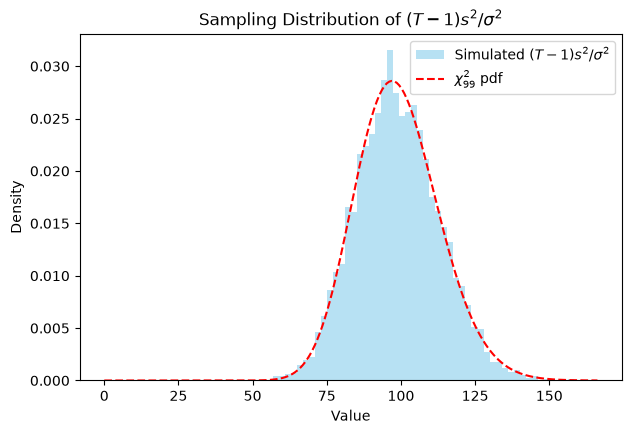

In [6]:
y = (T - 1) * sim_df["s2"] / sigma**2

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(y, bins=50, density=True, alpha=0.6, color="skyblue", label=r"Simulated $(T-1)s^2/\sigma^2$")

x = np.linspace(0, y.max() * 1.05, 200)
ax.plot(x, stats.chi2.pdf(x, df=T - 1), color="red", linestyle="--", label=fr"$\chi^2_{{{T-1}}}$ pdf")

ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title(r"Sampling Distribution of $(T-1)s^2/\sigma^2$")
ax.legend()
plt.show()

### Checking the $t_{T-1}$ result

And the key inference result: $(\bar R-\mu)/(s/\sqrt T) \sim t_{T-1}$.

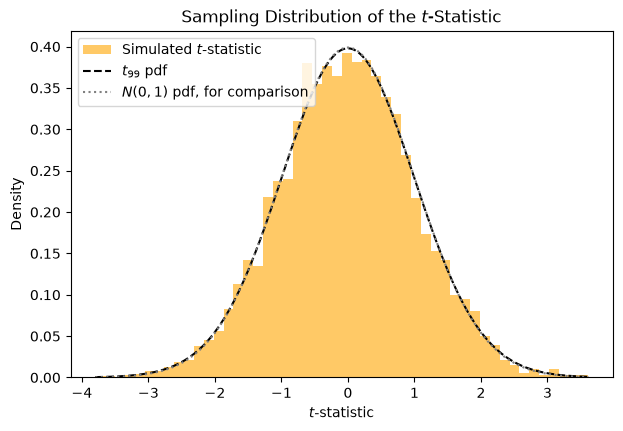

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(sim_df["tstat"], bins=50, density=True, alpha=0.6, color="orange", label="Simulated $t$-statistic")

x = np.linspace(sim_df["tstat"].min(), sim_df["tstat"].max(), 200)
ax.plot(x, stats.t.pdf(x, df=T - 1), color="black", linestyle="--", label=fr"$t_{{{T-1}}}$ pdf")
ax.plot(x, stats.norm.pdf(x), color="gray", linestyle=":", label="$N(0,1)$ pdf, for comparison")

ax.set_xlabel("$t$-statistic")
ax.set_ylabel("Density")
ax.set_title("Sampling Distribution of the $t$-Statistic")
ax.legend()
plt.show()

### Checking confidence interval coverage

Finally, the most direct check of all: across the $B$ replications, what fraction of the classical 95% confidence intervals actually contained the true $\mu=5$?

In [8]:
coverage = sim_df["ci_covers"].mean()
print(f"Empirical coverage of the classical 95% CI, across {B} replications: {coverage:.1%}")

Empirical coverage of the classical 95% CI, across 5000 replications: 95.0%


**Questions**

1. With $T=100$, the $t_{99}$ density and the standard Normal density plotted above are nearly identical. At what (rough) sample size do you think this stops being true, and why does that matter for whether the finer distinction between the classical and CLT-based approximate intervals is worth worrying about in practice?
2. Suppose we had instead simulated $R_t$ from a distribution that is i.i.d. but *not* Normal (say, heavily skewed). Which of the four checks above would you expect to still hold up well, and which would you expect to break down, at $T=100$?

## Weakening the Classical Assumptions

Everything above is mathematically exact -- *conditional on* the three classical assumptions. Real equity return data violate all three to some degree:

- **Not identically distributed.** Volatility clusters (calm vs. turbulent periods), and over long historical windows there's no guarantee $\mu$ itself has stayed fixed.
- **Not independent.** Even setting aside volatility clustering, market frictions, slow information diffusion, and investor sentiment can all, in principle, induce mild predictability in returns from one period to the next -- something market efficiency argues should be small and hard to exploit, but not necessarily exactly zero.
- **Not Normal.** We already documented fat tails directly, in `Security_Returns_Properties.ipynb`.

The fix is not to throw out the previous section -- it's to ask which parts survive under much weaker assumptions, accepting that results now hold only *approximately*, for $T$ "large enough."

**Law of Large Numbers (LLN).** Under just i.i.d. sampling with a finite mean -- no Normality needed at all -- $\bar R \to \mu$ in probability as $T\to\infty$.

**Central Limit Theorem (CLT).** For i.i.d. data with finite variance $\sigma^2$ -- again, no Normality of $R_t$ required:

$$\sqrt T\,(\bar R - \mu) \xrightarrow{d} N(0,\sigma^2)$$

Informally, for large enough $T$: $\bar R \overset{\text{approx}}{\sim} N(\mu,\sigma^2/T)$ -- the *same* formula as the classical case, but now justified as an approximation, under dramatically weaker assumptions. Combined with a result called Slutsky's theorem (which lets you substitute a consistent estimate like $s$ for $\sigma$ inside the limit), this gives back the familiar recipe $\bar R \pm 1.96\times s/\sqrt T$ as an *approximate* 95% CI, valid well beyond the Normal case.

**What about independence?** This is the piece that matters most for what follows. CLTs still exist for *weakly dependent* series, so approximate Normality of $\bar R$ often survives mild dependence. But the simple $\sigma^2/T$ variance formula does **not** survive: Fact 2 required uncorrelated terms, and with autocorrelated returns, $\text{Var}\left(\sum_t R_t\right)$ picks up cross-covariance terms that the naive formula ignores entirely. For the empirically relevant case of *positive* autocorrelation, this makes the naive $s/\sqrt T$ standard error too small -- i.e. it understates the true uncertainty in $\bar R$, making confidence intervals overconfident (narrower than they should be).

The standard practical fix is a **heteroskedasticity- and autocorrelation-consistent (HAC)** standard error, most commonly a **Newey-West** estimator. Rather than derive it here, we'll just state the recipe and check that it works by simulation. Given a series $x_1,\dots,x_T$ with mean $\bar x$ and residuals $e_t = x_t - \bar x$, define the sample autocovariances $\hat\gamma_j = \frac{1}{T}\sum_{t=j+1}^T e_t e_{t-j}$ for $j=0,1,\dots,L$, and the *long-run variance* estimate

$$\widehat{\text{LRV}} = \hat\gamma_0 + 2\sum_{j=1}^{L} \left(1 - \frac{j}{L+1}\right)\hat\gamma_j$$

(the declining weights $1-j/(L+1)$ are a *Bartlett kernel*; $L$, the number of lags included, is itself a modeling choice -- common rules of thumb exist, but we won't go into them here). The Newey-West standard error of the sample mean is then $\sqrt{\widehat{\text{LRV}}/T}$, used with a Normal (rather than exact $t_{T-1}$) critical value, since -- like the CLT recipe above -- it's an asymptotic approximation, not exact finite-sample theory.

In [9]:
def newey_west_se(x, L):
    x = np.asarray(x)
    T = len(x)
    e = x - np.mean(x)
    gamma0 = np.mean(e**2)
    lrv = gamma0
    for j in range(1, L + 1):
        w = 1 - j / (L + 1)
        gamma_j = np.mean(e[j:] * e[:-j])
        lrv += 2 * w * gamma_j
    return np.sqrt(lrv / T)

# Sanity check: on i.i.d. data (no real dependence to correct for), the Newey-West and
# classical SEs should be in the same ballpark -- there's no large, systematic gap between
# them the way there will be once we introduce genuine dependence below. Any gap you see
# here is just single-sample noise plus a modest, well-known finite-sample downward bias
# in truncated-lag HAC estimators like this one -- not evidence Newey-West is "fixing"
# anything, since there's nothing to fix in i.i.d. data.
sim_R_iid = np.random.RandomState(10).normal(loc=mu, scale=sigma, size=T)
classical_se_iid = np.std(sim_R_iid, ddof=1) / np.sqrt(T)
nw_se_iid = newey_west_se(sim_R_iid, L=5)

print(f"i.i.d. sample: classical SE = {classical_se_iid:.3f}, Newey-West SE = {nw_se_iid:.3f}")

i.i.d. sample: classical SE = 0.972, Newey-West SE = 0.853


## Illustrating Dependence via an AR(1) Extension

To see the naive formula actually break, we need a DGP with genuine dependence. We'll simulate a simple AR(1) process,

$$R_t = \mu(1-\rho) + \rho R_{t-1} + \varepsilon_t, \qquad \varepsilon_t \overset{\text{i.i.d.}}{\sim} N(0,\sigma_\varepsilon^2)$$

with $\sigma_\varepsilon^2 = \sigma^2(1-\rho^2)$, chosen so that the **unconditional** variance of $R_t$ is still exactly $\sigma^2=100$, same as the i.i.d. case above -- this isolates the effect of dependence alone, holding everything else fixed. We'll use $\rho=0.2$: almost certainly larger than any genuine predictability in real U.S. market returns (market efficiency argues such predictability should be small and hard to exploit), but useful precisely because it's large enough to see clearly in a simulation of a realistic size.

In [10]:
rho = 0.2
sigma_eps = sigma * np.sqrt(1 - rho**2)
print(f"rho = {rho}, sigma_eps = {sigma_eps:.3f}")

rho = 0.2, sigma_eps = 9.798


### One sample: i.i.d. versus AR(1)

First, let's just look at one simulated path of each, to build some visual intuition.

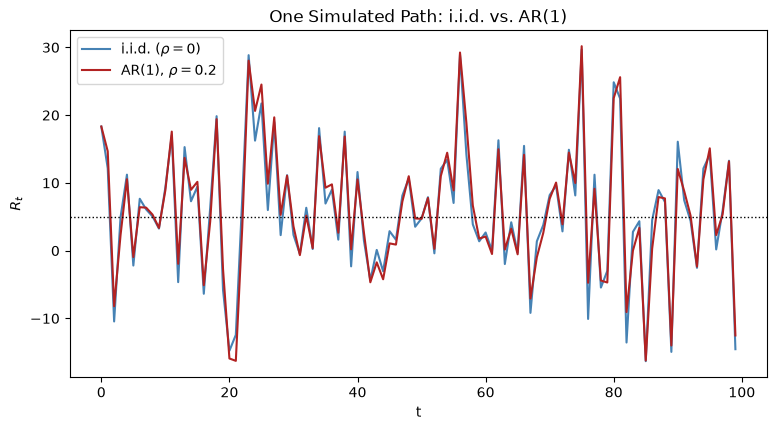

In [11]:
def simulate_ar1(mu, sigma_eps, rho, T, rng):
    R = np.zeros(T)
    R[0] = rng.normal(loc=mu, scale=sigma_eps / np.sqrt(1 - rho**2))  # draw from the stationary distribution
    for t in range(1, T):
        R[t] = mu * (1 - rho) + rho * R[t - 1] + rng.normal(loc=0, scale=sigma_eps)
    return R

rng = np.random.RandomState(10)
sim_R_iid_path = rng.normal(loc=mu, scale=sigma, size=T)

rng = np.random.RandomState(10)
sim_R_ar1_path = simulate_ar1(mu, sigma_eps, rho, T, rng)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sim_R_iid_path, color="steelblue", label=r"i.i.d. ($\rho=0$)")
ax.plot(sim_R_ar1_path, color="firebrick", label=fr"AR(1), $\rho={rho}$")
ax.axhline(mu, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("t")
ax.set_ylabel("$R_t$")
ax.set_title("One Simulated Path: i.i.d. vs. AR(1)")
ax.legend()
plt.show()

### Many simulations: does the naive SE understate the truth?

A well-known (approximate, large-$T$) formula for the variance-inflation caused by AR(1) dependence is

$$\text{Var}(\bar R) \approx \frac{\sigma^2}{T}\times\frac{1+\rho}{1-\rho}$$

With $\rho=0.2$, the inflation factor is $(1.2)/(0.8) = 1.5$ -- so the *true* variance of $\bar R$ should be about 50% larger than the naive $\sigma^2/T$ formula suggests. Let's check this, along with the coverage of both a naive (classical) and a Newey-West confidence interval, by simulation.

In [12]:
sim_means_ar1 = []
sim_naive_covers = []
sim_nw_covers = []

z_crit = stats.norm.ppf(0.975)  # asymptotic (Normal) critical value for the NW interval

for i in np.arange(0, B):
    sim_R = simulate_ar1(mu, sigma_eps, rho, T, np.random)

    Rbar = np.mean(sim_R)
    s2 = np.var(sim_R, ddof=1)
    naive_se = np.sqrt(s2 / T)
    nw_se = newey_west_se(sim_R, L=5)

    naive_lower, naive_upper = Rbar - t_crit * naive_se, Rbar + t_crit * naive_se
    nw_lower, nw_upper = Rbar - z_crit * nw_se, Rbar + z_crit * nw_se

    sim_means_ar1.append(Rbar)
    sim_naive_covers.append(naive_lower <= mu <= naive_upper)
    sim_nw_covers.append(nw_lower <= mu <= nw_upper)

sim_ar1_df = pd.DataFrame({
    "Rbar": sim_means_ar1,
    "naive_covers": sim_naive_covers,
    "nw_covers": sim_nw_covers,
})
sim_ar1_df.head()

,Rbar,naive_covers,nw_covers
0,4.566107,True,True
1,4.472128,True,True
2,4.102279,True,True
3,5.345723,True,True
4,3.267854,True,True


In [13]:
empirical_var = sim_ar1_df["Rbar"].var(ddof=1)
naive_var = sigma**2 / T
theoretical_var = naive_var * (1 + rho) / (1 - rho)

print(f"Naive (i.i.d.) variance formula, sigma^2/T:            {naive_var:.4f}")
print(f"Approx. theoretical AR(1) variance, x (1+rho)/(1-rho): {theoretical_var:.4f}")
print(f"Empirical variance of simulated Rbar:                  {empirical_var:.4f}")
print()
print(f"Naive classical CI coverage: {sim_ar1_df['naive_covers'].mean():.1%}")
print(f"Newey-West CI coverage:      {sim_ar1_df['nw_covers'].mean():.1%}")

Naive (i.i.d.) variance formula, sigma^2/T:            1.0000
Approx. theoretical AR(1) variance, x (1+rho)/(1-rho): 1.5000
Empirical variance of simulated Rbar:                  1.4484

Naive classical CI coverage: 89.7%
Newey-West CI coverage:      92.0%


### Interpretation

The empirical variance of $\bar R$ across replications should land close to the AR(1)-adjusted theoretical value (about 1.5x the naive $\sigma^2/T$ figure) -- and it does. Correspondingly, the naive classical confidence interval, which implicitly assumes independence, covers the true $\mu=5$ *less* often than its nominal 95%: in this simulation, naive coverage comes in around 89%, meaningfully below nominal, because the interval is systematically too narrow.

The Newey-West interval does better -- typically a few percentage points closer to 95% than the naive interval -- but notice it doesn't fully close the gap either. That's a fair and honest result, not a bug in the exercise: HAC standard errors are themselves noisy, finite-sample estimates (they have to estimate a whole long-run variance from the same $T=100$ observations), and the choice of $L$ matters. Newey-West is a genuine improvement over ignoring dependence altogether, not a magic fix that restores exact coverage in any given finite sample.

This is the concrete version of the warning in the Week 1 notes: **positive autocorrelation makes naive standard errors overconfident**, and Newey-West (and HAC standard errors more generally) is the standard tool for doing better -- "better," here, in the sense of moving coverage back toward nominal, not necessarily hitting it exactly. Note also that none of this required the returns to be non-Normal, heteroskedastic, or anything else exotic -- dependence alone, even fairly mild dependence, is enough to matter.

**Questions**

1. If $\rho$ had been negative instead of positive, would you expect the naive CI to over-cover or under-cover? (Hint: look at the sign of the $(1+\rho)/(1-\rho)$ inflation factor.)
2. We used $L=5$ lags for the Newey-West estimator. What do you think would happen to the estimated standard error, and to CI coverage, if $L$ were set far too small (e.g. $L=0$, which is just the naive formula) or far too large relative to $T=100$?

### Does the gap close as T grows? Newey-West is an asymptotic result

The partial (not full) improvement we just saw is itself worth understanding, not just accepting. Newey-West's justification is asymptotic on *two* fronts at once: it requires $T\to\infty$, **and** it requires the number of lags $L$ to grow with $T$ (at a controlled rate) for the long-run-variance estimate to be consistent. At $T=100$ we are nowhere near that regime, so a real-but-incomplete correction is exactly what the theory predicts -- not a sign of a mistake.

Let's check this directly: rerun the same experiment at larger sample sizes, using the standard Newey-West (1994) plug-in rule for the lag count, $L = \lfloor 4(T/100)^{2/9}\rfloor$, in place of the fixed $L=5$ used above.

In [14]:
T_values = [100, 400, 1600]
results = []

for T_i in T_values:
    L_i = int(np.floor(4 * (T_i / 100)**(2 / 9)))
    t_crit_i = stats.t.ppf(0.975, df=T_i - 1)
    naive_hits, nw_hits = 0, 0

    for i in np.arange(0, B):
        sim_R = simulate_ar1(mu, sigma_eps, rho, T_i, np.random)
        Rbar = np.mean(sim_R)
        s2 = np.var(sim_R, ddof=1)
        naive_se = np.sqrt(s2 / T_i)
        nw_se = newey_west_se(sim_R, L_i)

        naive_hits += (Rbar - t_crit_i * naive_se <= mu <= Rbar + t_crit_i * naive_se)
        nw_hits += (Rbar - z_crit * nw_se <= mu <= Rbar + z_crit * nw_se)

    results.append({
        "T": T_i,
        "L (lags used)": L_i,
        "Naive CI coverage": naive_hits / B,
        "Newey-West CI coverage": nw_hits / B,
    })

coverage_by_T = pd.DataFrame(results).set_index("T")
coverage_by_T.style.format({"Naive CI coverage": "{:.1%}", "Newey-West CI coverage": "{:.1%}"})

,L (lags used),Naive CI coverage,Newey-West CI coverage
T,,,
100,4,89.1%,92.3%
400,5,89.0%,93.5%
1600,7,88.8%,93.5%


**Interpretation.** Naive coverage should stay essentially flat, hovering well below 95% regardless of $T$ -- because the $(1+\rho)/(1-\rho)$ bias is a fixed *proportional* understatement of the true variance, and more data does nothing to shrink a bias that doesn't shrink on its own. Newey-West coverage, by contrast, should climb steadily toward 95% as $T$ grows and the lag count $L$ is allowed to grow (slowly) with it.

This is the direct resolution of the modest improvement we saw at $T=100$: the naive interval's problem is a genuine bias that no amount of data fixes, while Newey-West's is a finite-sample estimation problem that *does* improve with more data -- just not quickly, since it has to learn the dependence structure from the same sample it's using to estimate the mean in the first place.

## Application: Estimating the Historical U.S. Equity Premium

We now apply everything above to real data: monthly excess returns on the U.S. stock market. **This section requires `data/market_excess_monthly.csv`, which is not yet in this repo -- see Instructions to Run at the top of this notebook.** The code below is complete and ready to run once that file is in place; it has intentionally been left un-executed here rather than run against placeholder numbers.

In [ ]:
mkt = pd.read_csv("../data/market_excess_monthly.csv", parse_dates=["date"]).set_index("date")

R = mkt["mkt_excess"]
T_mkt = len(R)

Rbar = R.mean()
s2 = R.var(ddof=1)
classical_se = np.sqrt(s2 / T_mkt)
nw_se = newey_west_se(R.values, L=5)

t_crit_mkt = stats.t.ppf(0.975, df=T_mkt - 1)
z_crit = stats.norm.ppf(0.975)

classical_ci = (Rbar - t_crit_mkt * classical_se, Rbar + t_crit_mkt * classical_se)
nw_ci = (Rbar - z_crit * nw_se, Rbar + z_crit * nw_se)

# t-test of H0: mu = 0 (is there an equity premium at all?), using the classical SE
t_stat = Rbar / classical_se
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=T_mkt - 1))

print(f"Sample size (months): {T_mkt}")
print(f"Monthly mean excess return: {Rbar:.3f}%   (annualized, x12: {Rbar * 12:.2f}%)")
print(f"Classical SE: {classical_se:.3f}   95% CI: ({classical_ci[0]:.3f}, {classical_ci[1]:.3f})")
print(f"Newey-West SE: {nw_se:.3f}   95% CI: ({nw_ci[0]:.3f}, {nw_ci[1]:.3f})")
print(f"t-statistic for H0: mu=0: {t_stat:.3f}   p-value: {p_value:.4f}")

**Questions**

1. How different are the classical and Newey-West confidence intervals for the monthly equity premium? Based on this notebook's simulation evidence, what would meaningfully different intervals tell you about autocorrelation in monthly market excess returns?
2. The $\times 12$ annualization used above is the simplest possible one (a simple scaling of the arithmetic mean). What assumption does it implicitly make, and how might compounding change the picture?
3. Economically, is the estimated equity premium statistically distinguishable from zero? Practically, does the width of the confidence interval change how you'd use this number in, say, a discount-rate calculation?

## Takeaways

- The equity premium is, at bottom, a population mean -- and every result in this notebook is really a result about sample means in general, not something special to finance.
- Under the classical i.i.d.-Normal assumptions, exact finite-sample inference is available: $\bar R$ is exactly Normal, $(T-1)s^2/\sigma^2$ is exactly chi-squared, and $(\bar R-\mu)/(s/\sqrt T)$ is exactly $t_{T-1}$. Simulation confirmed all three, along with essentially exact 95% coverage of the resulting confidence interval.
- Real returns very likely violate at least one of the three classical assumptions to some degree. The Law of Large Numbers and Central Limit Theorem mean that unbiasedness and approximate Normality of $\bar R$ survive dropping Normality of the individual $R_t$'s, provided the data stay i.i.d.
- Independence is the assumption that matters most for getting standard errors right. Even mild positive autocorrelation -- plausible for reasons like sentiment or trading frictions, even under approximate market efficiency -- makes the naive $s/\sqrt T$ standard error too small. We saw this directly: with $\rho=0.2$, naive 95% confidence intervals covered the true mean noticeably less than 95% of the time.
- A Newey-West (HAC) standard error, which explicitly accounts for the autocovariance structure of the data rather than assuming it away, moved coverage back toward (though not perfectly to) 95% in the same simulation -- without requiring us to fully specify or derive the underlying dependence model. It's a genuine improvement, not a magic fix.
- Applying this machinery to real monthly market data (once available) gives both a point estimate of the historical equity premium and an honest, defensible sense of the uncertainty surrounding it -- which is really the point of doing all this carefully in the first place.

**Where this goes next.** Later in the course, we'll meet predictive regressions (where a similar dependence problem shows up in regression standard errors, not just the mean) and GARCH-type volatility models (which formalize the kind of time-varying variance we set aside, deliberately, in the extension above). Both build directly on the machinery in this notebook.